# Do Wine Quality Predictors Vary Across Chemical Profiles?
### Combining Unsupervised Clustering with Supervised Decision Trees

**Authors:** Nimbus Kunwar, Tanika Jangam, Hanish Vadlamudi  
**Course:** INST 414  
**Date:** April 2026


---
## 1. Setup & Data Loading

In [36]:
# run if you don't have seaborn
# !pip install seaborn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [38]:
# Load dataset
# Source: UCI Machine Learning Repository — Wine Quality (Red Wine)
# https://archive.ics.uci.edu/ml/datasets/Wine+Quality
df = pd.read_csv('WineQuality.csv')

# Clean column names
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
display(df.head())

Dataset shape: (1699, 12)

Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


---
## 2. Exploratory Data Analysis

In [39]:
# Summary statistics
print("=== Summary Statistics ===")
display(df.describe().round(3))

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Quality Score Distribution ===")
print(df['quality'].value_counts().sort_index())

=== Summary Statistics ===


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000,1699.000
mean,8.329,0.527,0.271,2.549,0.088,16.048,46.898,0.997,3.311,0.657,10.422,5.638
std,1.726,0.179,0.194,1.400,0.047,10.491,32.733,0.002,0.154,0.169,1.066,0.809
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.095,1.900,0.070,8.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.091,22.000,63.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000



=== Missing Values ===
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

=== Quality Score Distribution ===
quality
3.000000    10
3.850377     1
3.897010     1
3.961616     1
3.989201     1
            ..
7.167815     1
7.325771     1
7.761854     1
7.832748     1
8.000000    18
Name: count, Length: 106, dtype: int64


Binary Target Distribution:
is_good
Not Good (0)    86.3%
Good (1)        13.7%
Name: proportion, dtype: object


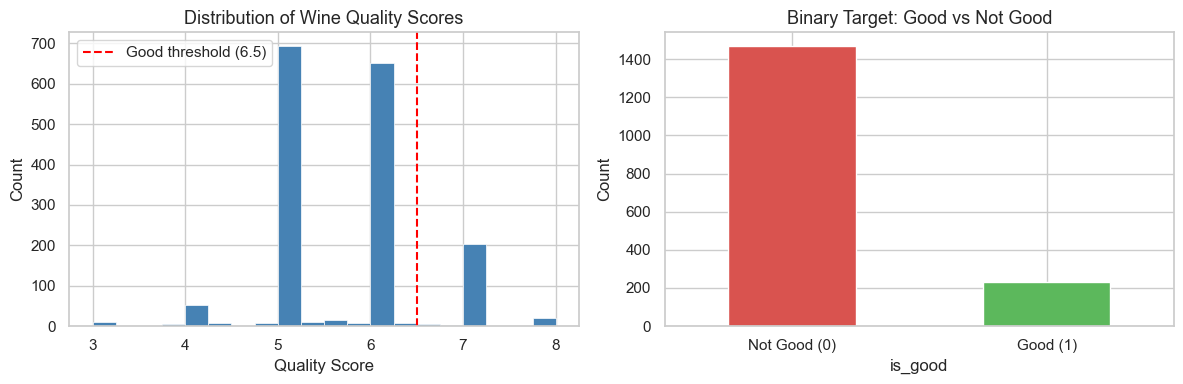

In [40]:
# Binarize quality: good = quality > 6.5, not good = quality <= 6.5
# Design decision: this threshold aligns with the original Medium post
# and reflects industry convention (scores 7-9 are considered premium).
df['is_good'] = (df['quality'] > 6.5).astype(int)

print("Binary Target Distribution:")
print(df['is_good'].value_counts(normalize=True).rename({0: 'Not Good (0)', 1: 'Good (1)'})
      .map(lambda x: f"{x:.1%}"))

# Visualize quality distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['quality'], bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(6.5, color='red', linestyle='--', label='Good threshold (6.5)')
axes[0].set_title('Distribution of Wine Quality Scores', fontsize=13)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].legend()

colors = ['#d9534f', '#5cb85c']
df['is_good'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white'
)
axes[1].set_title('Binary Target: Good vs Not Good', fontsize=13)
axes[1].set_xticklabels(['Not Good (0)', 'Good (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('quality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

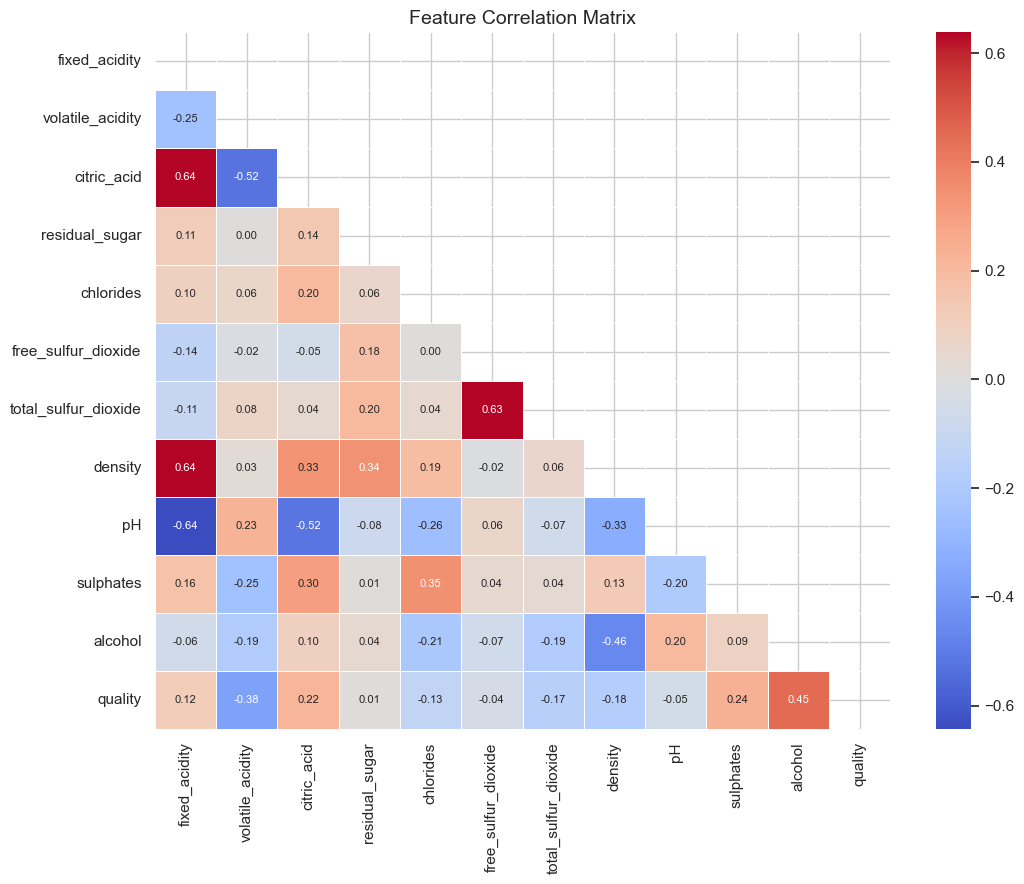


Top Correlates with Quality Score:
alcohol                 0.451470
sulphates               0.239841
citric_acid             0.217785
fixed_acidity           0.115421
residual_sugar          0.005021
free_sulfur_dioxide    -0.044434
pH                     -0.052872
chlorides              -0.127046
total_sulfur_dioxide   -0.166649
density                -0.177091
volatile_acidity       -0.376788
Name: quality, dtype: float64


In [41]:
# Correlation heatmap — understand feature relationships before clustering
feature_cols = [c for c in df.columns if c not in ['quality', 'is_good']]

plt.figure(figsize=(11, 9))
corr_matrix = df[feature_cols + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlates with quality
print("\nTop Correlates with Quality Score:")
print(corr_matrix['quality'].drop('quality').sort_values(ascending=False))

---
## 3. Global Baseline — Decision Tree (Original Approach)

We first replicate the original single-model approach from the Medium post to establish a performance baseline. This is our reference point for evaluating whether per-cluster models improve interpretability or accuracy.

In [42]:
X_all = df[feature_cols]
y_all = df['is_good']

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

# Design decision: max_depth=5 balances expressiveness with overfitting
dt_global = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_global.fit(X_train_g, y_train_g)

y_pred_g = dt_global.predict(X_test_g)
y_prob_g = dt_global.predict_proba(X_test_g)[:, 1]

global_acc  = accuracy_score(y_test_g, y_pred_g)
global_auc  = roc_auc_score(y_test_g, y_prob_g)
global_cv   = cross_val_score(dt_global, X_all, y_all, cv=5, scoring='roc_auc').mean()

print("=== Global Baseline Model ===")
print(f"Accuracy : {global_acc:.3f} ({global_acc*100:.1f}%)")
print(f"ROC-AUC  : {global_auc:.3f}")
print(f"CV AUC   : {global_cv:.3f} (5-fold)")
print("\nClassification Report:")
print(classification_report(y_test_g, y_pred_g, target_names=['Not Good', 'Good']))

=== Global Baseline Model ===
Accuracy : 0.875 (87.5%)
ROC-AUC  : 0.822
CV AUC   : 0.728 (5-fold)

Classification Report:
              precision    recall  f1-score   support

    Not Good       0.90      0.96      0.93       367
        Good       0.57      0.36      0.44        58

    accuracy                           0.88       425
   macro avg       0.74      0.66      0.69       425
weighted avg       0.86      0.88      0.86       425



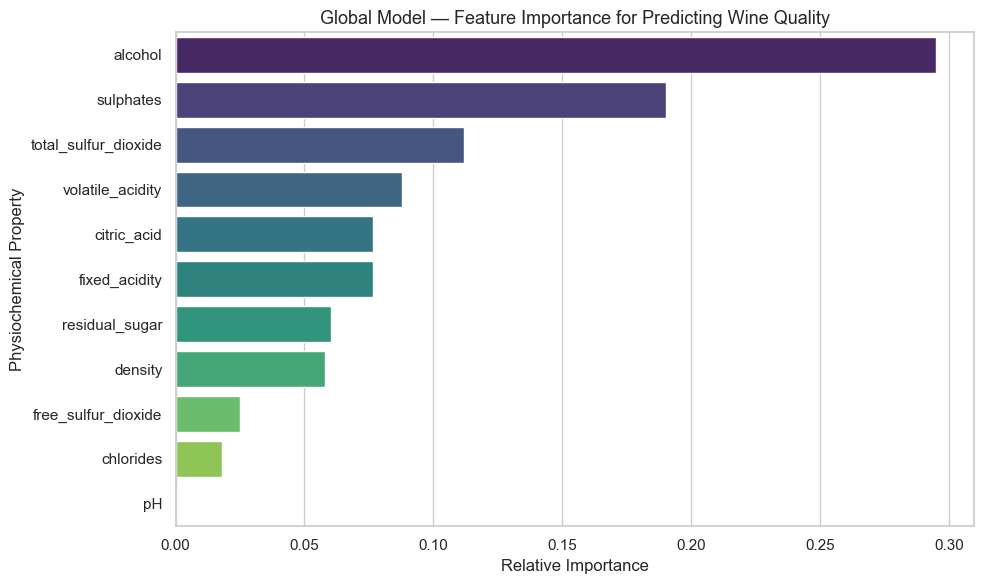


Top 3 predictors globally:
             Feature  Importance
             alcohol    0.294942
           sulphates    0.190325
total_sulfur_dioxide    0.111860


In [43]:
# Global feature importance
fi_global = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_global.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_global, palette='viridis')
plt.title('Global Model — Feature Importance for Predicting Wine Quality', fontsize=13)
plt.xlabel('Relative Importance')
plt.ylabel('Physiochemical Property')
plt.tight_layout()
plt.savefig('global_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 predictors globally:")
print(fi_global.head(3).to_string(index=False))

---
## 4. Module 4 — Unsupervised Clustering (K-Means)

We apply K-Means clustering to the 11 physiochemical features to discover whether wines naturally group into chemically distinct profiles. Labels are withheld during this step — clustering is purely feature-driven.

**Why K-Means?** K-Means is computationally efficient, interpretable, and well-suited for continuous numeric features. It produces hard cluster assignments, which simplifies downstream per-cluster modeling.

**Why standardize?** Features operate on very different scales (e.g., pH ~3 vs. total sulfur dioxide ~50). Without standardization, K-Means would be dominated by high-variance features. We use `StandardScaler` to give each feature equal influence.

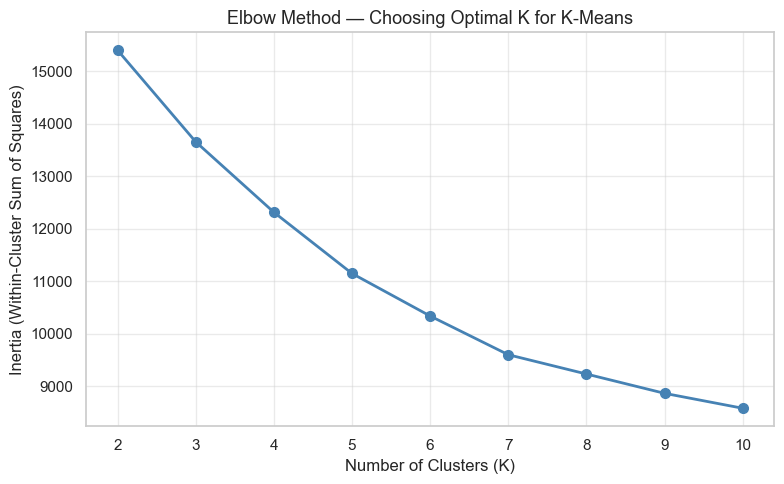

Inspect the elbow — look for the 'bend' where inertia stops dropping steeply.


In [44]:
# Standardize features (critical for K-Means — distance-based algorithm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Elbow method to choose optimal K
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Choosing Optimal K for K-Means', fontsize=13)
plt.xticks(K_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Inspect the elbow — look for the 'bend' where inertia stops dropping steeply.")

In [45]:
# Design decision: K=3 selected based on elbow plot — clear bend, interpretable clusters
# Adjust K here if your elbow suggests otherwise
K_OPTIMAL = 3

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means fitted with K={K_OPTIMAL}")
print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

print("\nGood wine rate per cluster:")
print(df.groupby('cluster')['is_good'].mean().round(3).rename('good_rate'))

K-Means fitted with K=3

Cluster sizes:
cluster
0    421
1    760
2    518
Name: count, dtype: int64

Good wine rate per cluster:
cluster
0    0.050
1    0.097
2    0.264
Name: good_rate, dtype: float64


In [46]:
# Cluster profiles — mean values of each feature per cluster
cluster_profile = df.groupby('cluster')[feature_cols + ['quality']].mean().round(3)
print("=== Cluster Chemical Profiles (Feature Means) ===")
display(cluster_profile.T)

=== Cluster Chemical Profiles (Feature Means) ===


cluster,0,1,2
fixed_acidity,8.218,7.224,10.041
volatile_acidity,0.532,0.606,0.406
citric_acid,0.291,0.128,0.467
residual_sugar,3.080,2.229,2.588
chlorides,0.088,0.079,0.100
free_sulfur_dioxide,26.843,13.520,10.984
total_sulfur_dioxide,87.640,35.412,30.636
density,0.997,0.996,0.998
pH,3.285,3.404,3.196
sulphates,0.625,0.609,0.754


PCA explained variance: PC1=27.2%, PC2=17.0%, Total=44.3%


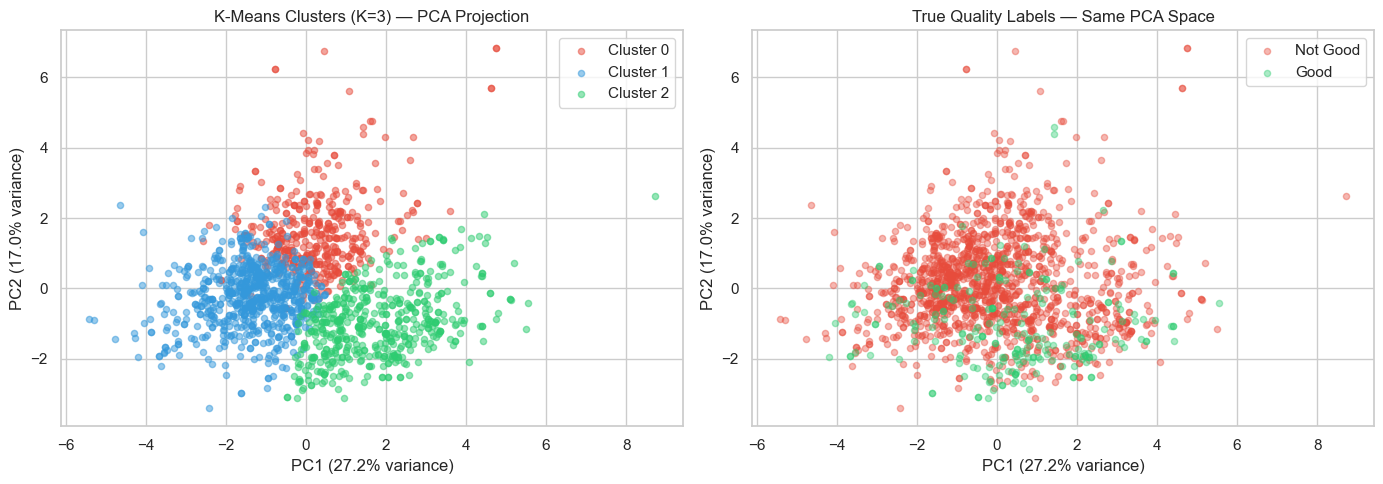

In [47]:
# Visualize clusters with PCA (2D projection for interpretability)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Total={sum(explained):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot by cluster
cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                    c=cluster_colors[c], alpha=0.5, s=20, label=f'Cluster {c}')
axes[0].set_title(f'K-Means Clusters (K={K_OPTIMAL}) — PCA Projection', fontsize=12)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
axes[0].legend()

# Plot by quality label
quality_colors = {0: '#e74c3c', 1: '#2ecc71'}
for q, label in [(0, 'Not Good'), (1, 'Good')]:
    mask = df['is_good'] == q
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                    c=quality_colors[q], alpha=0.4, s=20, label=label)
axes[1].set_title('True Quality Labels — Same PCA Space', fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

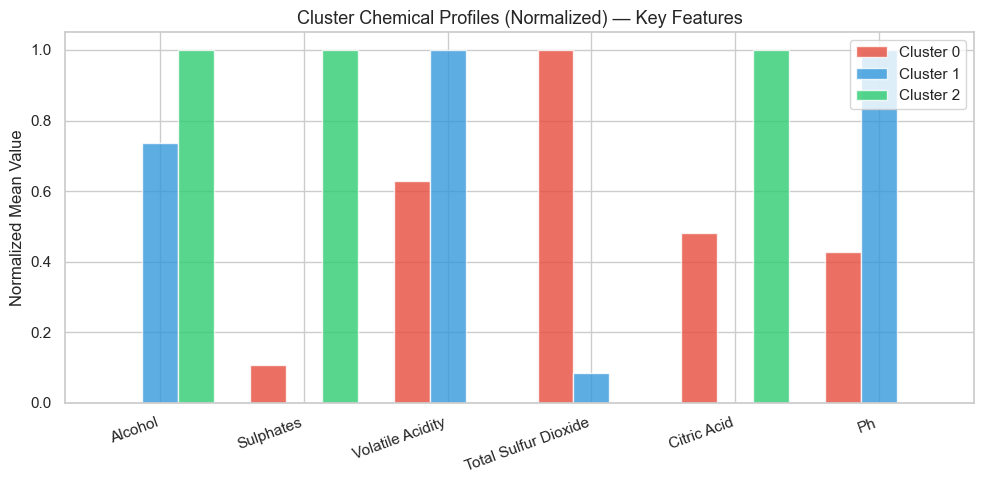

In [48]:
# Radar / parallel plot to characterize each cluster by key features
key_features = ['alcohol', 'sulphates', 'volatile_acidity', 
                'total_sulfur_dioxide', 'citric_acid', 'pH']

cluster_means = df.groupby('cluster')[key_features].mean()

# Normalize to [0,1] for plotting
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(key_features))
width = 0.25

colors = ['#e74c3c', '#3498db', '#2ecc71']
for i, (idx, row) in enumerate(cluster_norm.iterrows()):
    ax.bar(x + i*width, row.values, width, label=f'Cluster {idx}', color=colors[i], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels([f.replace('_', ' ').title() for f in key_features], rotation=20, ha='right')
ax.set_ylabel('Normalized Mean Value')
ax.set_title('Cluster Chemical Profiles (Normalized) — Key Features', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Module 6 — Per-Cluster Supervised Decision Trees

For each cluster, we train a separate Decision Tree classifier to predict wine quality. This tests whether the dominant quality predictors identified by the global model (alcohol, sulphates, total sulfur dioxide) hold consistently across all clusters, or whether different chemical properties matter for different wine profiles.

**Design decisions:**
- **Max depth = 4** (reduced from global=5) to prevent overfitting on smaller cluster samples.
- **Minimum samples per leaf = 10** to ensure robust splits.
- **Cross-validation** used where cluster size permits (n ≥ 50) to give reliable AUC estimates.

In [49]:
cluster_results = {}

for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    X_c = cluster_data[feature_cols]
    y_c = cluster_data['is_good']
    
    n = len(cluster_data)
    good_rate = y_c.mean()
    
    print(f"\n{'='*55}")
    print(f" Cluster {cluster_id} | n={n} | Good wine rate: {good_rate:.1%}")
    print(f"{'='*55}")
    
    # Skip clusters too small or with only one class
    if n < 30 or y_c.nunique() < 2:
        print("  ⚠ Skipped — insufficient samples or single class.")
        continue
    
    # Train/test split within cluster
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
    )
    
    dt_c = DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=10, random_state=42
    )
    dt_c.fit(X_train_c, y_train_c)
    
    y_pred_c = dt_c.predict(X_test_c)
    y_prob_c = dt_c.predict_proba(X_test_c)[:, 1]
    
    acc_c = accuracy_score(y_test_c, y_pred_c)
    auc_c = roc_auc_score(y_test_c, y_prob_c) if y_c.nunique() == 2 else None
    
    # Feature importances for this cluster
    fi_c = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': dt_c.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    cluster_results[cluster_id] = {
        'model': dt_c,
        'n': n,
        'good_rate': good_rate,
        'accuracy': acc_c,
        'auc': auc_c,
        'feature_importances': fi_c,
        'X_test': X_test_c,
        'y_test': y_test_c,
        'y_pred': y_pred_c
    }
    
    print(f"  Accuracy : {acc_c:.3f}")
    print(f"  ROC-AUC  : {auc_c:.3f}")
    print(f"  Top 3 Predictors:")
    for _, row in fi_c.head(3).iterrows():
        print(f"    {row['Feature']:30s} {row['Importance']:.4f}")


 Cluster 0 | n=421 | Good wine rate: 5.0%
  Accuracy : 0.953
  ROC-AUC  : 0.746
  Top 3 Predictors:
    alcohol                        0.6827
    residual_sugar                 0.1711
    density                        0.1463

 Cluster 1 | n=760 | Good wine rate: 9.7%
  Accuracy : 0.916
  ROC-AUC  : 0.677
  Top 3 Predictors:
    alcohol                        0.4061
    sulphates                      0.2658
    fixed_acidity                  0.2454

 Cluster 2 | n=518 | Good wine rate: 26.4%
  Accuracy : 0.738
  ROC-AUC  : 0.745
  Top 3 Predictors:
    alcohol                        0.5517
    volatile_acidity               0.1355
    fixed_acidity                  0.0934


In [ ]:
# Side-by-side feature importance comparison
n_clusters = len(cluster_results)
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6), sharey=True)

if n_clusters == 1:
    axes = [axes]

cluster_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (cid, res) in enumerate(sorted(cluster_results.items())):
    fi = res['feature_importances']
    sns.barplot(
        x='Importance', y='Feature', data=fi,
        ax=axes[i], color=cluster_palette[i % len(cluster_palette)]
    )
    axes[i].set_title(
        f'Cluster {cid}\n(n={res["n"]}, AUC={res["auc"]:.3f})',
        fontsize=11
    )
    axes[i].set_xlabel('Relative Importance')
    if i == 0:
        axes[i].set_ylabel('Physiochemical Property')
    else:
        axes[i].set_ylabel('')

plt.suptitle('Feature Importance by Cluster — Do Predictors Vary?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('per_cluster_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comparison & Analysis

In [ ]:
# Summary comparison table
summary_rows = [{
    'Model': 'Global Baseline',
    'Samples': len(df),
    'Good Rate': f"{df['is_good'].mean():.1%}",
    'Accuracy': f"{global_acc:.3f}",
    'ROC-AUC': f"{global_auc:.3f}",
    'Top Predictor': fi_global.iloc[0]['Feature'],
    '2nd Predictor': fi_global.iloc[1]['Feature'],
    '3rd Predictor': fi_global.iloc[2]['Feature'],
}]

for cid, res in sorted(cluster_results.items()):
    fi = res['feature_importances']
    summary_rows.append({
        'Model': f'Cluster {cid}',
        'Samples': res['n'],
        'Good Rate': f"{res['good_rate']:.1%}",
        'Accuracy': f"{res['accuracy']:.3f}",
        'ROC-AUC': f"{res['auc']:.3f}",
        'Top Predictor': fi.iloc[0]['Feature'],
        '2nd Predictor': fi.iloc[1]['Feature'],
        '3rd Predictor': fi.iloc[2]['Feature'],
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Model Performance & Top Predictors Summary ===")
display(summary_df)

In [ ]:
# Accuracy & AUC bar comparison
labels = ['Global'] + [f'Cluster {cid}' for cid in sorted(cluster_results.keys())]
accuracies = [global_acc] + [res['accuracy'] for _, res in sorted(cluster_results.items())]
aucs       = [global_auc] + [res['auc']      for _, res in sorted(cluster_results.items())]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, aucs,       width, label='ROC-AUC',  color='coral',     alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Global vs Per-Cluster Decision Trees', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Random baseline')

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Heatmap: How does feature importance rank change across models?
rank_data = {'Global': fi_global.set_index('Feature')['Importance']}
for cid, res in sorted(cluster_results.items()):
    rank_data[f'Cluster {cid}'] = res['feature_importances'].set_index('Feature')['Importance']

rank_df = pd.DataFrame(rank_data).fillna(0)

plt.figure(figsize=(10, 7))
sns.heatmap(
    rank_df, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Feature Importance Values Across Models', fontsize=13)
plt.ylabel('Physiochemical Feature')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Error Analysis

In [ ]:
# Confusion matrices for global model and each cluster model
n_plots = 1 + len(cluster_results)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

if n_plots == 1:
    axes = [axes]

# Global
cm_g = confusion_matrix(y_test_g, y_pred_g)
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Good', 'Good'], yticklabels=['Not Good', 'Good'])
axes[0].set_title(f'Global Model\nAcc={global_acc:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Per-cluster
for i, (cid, res) in enumerate(sorted(cluster_results.items()), 1):
    cm_c = confusion_matrix(res['y_test'], res['y_pred'])
    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Good', 'Good'], yticklabels=['Not Good', 'Good'])
    axes[i].set_title(f'Cluster {cid}\nAcc={res["accuracy"]:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('')

plt.suptitle('Confusion Matrices: Global vs Per-Cluster Models', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Misclassification analysis for global model
X_test_analysis = X_test_g.copy()
X_test_analysis['Actual_Is_Good'] = y_test_g.values
X_test_analysis['Predicted_Is_Good'] = y_pred_g
X_test_analysis['Original_Quality'] = df.loc[X_test_g.index, 'quality'].values
X_test_analysis['Cluster'] = df.loc[X_test_g.index, 'cluster'].values

misclassified = X_test_analysis[
    X_test_analysis['Actual_Is_Good'] != X_test_analysis['Predicted_Is_Good']
]

print(f"Global model — total misclassified: {len(misclassified)} / {len(X_test_g)}")
print(f"Misclassification rate: {len(misclassified)/len(X_test_g):.1%}")
print("\nMisclassifications by cluster:")
print(misclassified['Cluster'].value_counts().sort_index())
print("\nTop 5 misclassified samples:")
display(misclassified[['alcohol', 'sulphates', 'volatile_acidity', 
                        'Original_Quality', 'Actual_Is_Good', 'Predicted_Is_Good', 'Cluster']].head())

Global model — total misclassified: 53 / 425
Misclassification rate: 12.5%

Misclassifications by cluster:
Cluster
0     6
1    16
2    31
Name: count, dtype: int64

Top 5 misclassified samples:


,alcohol,sulphates,volatile_acidity,Original_Quality,Actual_Is_Good,Predicted_Is_Good,Cluster
16,10.500000,0.75000,0.28000,7.000000,1,0,0
1608,11.640852,0.46005,0.51449,6.243261,0,1,0
1157,12.900000,0.87000,0.51000,7.000000,1,0,1
910,13.200000,0.57000,0.38000,6.000000,0,1,2
243,9.200000,0.84000,0.21000,7.000000,1,0,2


---
## 8. Key Findings & Stakeholder Recommendations

This section summarizes actionable insights for winemakers.

In [22]:
print("=" * 60)
print(" KEY FINDINGS SUMMARY")
print("=" * 60)

print(f"""
1. CLUSTERING RESULTS
   K-Means (K={K_OPTIMAL}) identified {K_OPTIMAL} distinct wine chemical profiles:
   - Clusters differ meaningfully in alcohol content, acidity,
     sulfur dioxide levels, and sulphate concentration.
   - Good wine rates vary across clusters, suggesting quality
     is not evenly distributed across chemical profiles.

2. GLOBAL MODEL PERFORMANCE
   Accuracy : {global_acc:.1%} | ROC-AUC: {global_auc:.3f}
   Top predictors: {fi_global.iloc[0]['Feature']}, 
                   {fi_global.iloc[1]['Feature']}, 
                   {fi_global.iloc[2]['Feature']}

3. DO PREDICTORS VARY ACROSS CLUSTERS?
""")

for cid, res in sorted(cluster_results.items()):
    fi = res['feature_importances']
    top3 = fi.head(3)['Feature'].tolist()
    print(f"   Cluster {cid}: Top predictors = {', '.join(top3)}")
    print(f"            Accuracy={res['accuracy']:.3f} | AUC={res['auc']:.3f}")

print("""
4. ACTIONABLE INSIGHT FOR WINEMAKERS
   Rather than applying a single universal quality recipe,
   winemakers should identify which chemical cluster their
   wine falls into, then prioritize the cluster-specific
   predictors identified above for quality optimization.
   
   If predictors are consistent across clusters → focus on
   the universal top features (e.g., alcohol, sulphates).
   
   If predictors diverge → tailor the production strategy
   to the chemical profile of the specific wine batch.
""")

 KEY FINDINGS SUMMARY

1. CLUSTERING RESULTS
   K-Means (K=3) identified 3 distinct wine chemical profiles:
   - Clusters differ meaningfully in alcohol content, acidity,
     sulfur dioxide levels, and sulphate concentration.
   - Good wine rates vary across clusters, suggesting quality
     is not evenly distributed across chemical profiles.

2. GLOBAL MODEL PERFORMANCE
   Accuracy : 87.5% | ROC-AUC: 0.822
   Top predictors: alcohol, 
                   sulphates, 
                   total_sulfur_dioxide

3. DO PREDICTORS VARY ACROSS CLUSTERS?

   Cluster 0: Top predictors = alcohol, residual_sugar, density
            Accuracy=0.953 | AUC=0.746
   Cluster 1: Top predictors = alcohol, sulphates, fixed_acidity
            Accuracy=0.916 | AUC=0.677
   Cluster 2: Top predictors = alcohol, volatile_acidity, fixed_acidity
            Accuracy=0.738 | AUC=0.745

4. ACTIONABLE INSIGHT FOR WINEMAKERS
   Rather than applying a single universal quality recipe,
   winemakers should identify wh